In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
import operator

In [2]:
generator_llm = ChatGroq(model="openai/gpt-oss-20b")
evaluator_llm = ChatGroq(model="openai/gpt-oss-20b")
optimizer_llm = ChatGroq(model="openai/gpt-oss-20b")

In [3]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):

    evaluation: Literal["Approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [4]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [5]:
# create a state

class TweetState(TypedDict):
    
    topic: str
    tweet: str
    evaluation: Literal["Approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [6]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
- This is version {state['iteration'] + 1}.
""")
    ]

    # send to generator llm

    response = generator_llm.invoke(messages).content

    # return response

    return {'tweet': response, 'tweet_history': [response]}



In [7]:
import re


def evaluate_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor

Respond ONLY as valid JSON with keys:
{{
  "evaluation": "Approved" or "needs_improvement",
  "feedback": "One paragraph explaining the strengths and weaknesses"
}}
""")
    ]

    response_text = evaluator_llm.invoke(messages).content

    try:
        parsed = TweetEvaluation.model_validate_json(response_text)
    except Exception:
        match = re.search(r"\{.*\}", response_text, re.S)
        if not match:
            raise
        parsed = TweetEvaluation.model_validate_json(match.group(0))

    return {'evaluation': parsed.evaluation, 'feedback': parsed.feedback, 'feedback_history': [parsed.feedback]}

In [8]:
def optimize_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    # send to optimizer llm
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    # return to state
    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [9]:
def route_evaluation(state:TweetState):
    if state['evaluation'] == 'Approved' or state['iteration'] >= state['max_iteration']:
        return 'Approved'
    else:
        return 'needs_improvement'

In [10]:
# define graph 

graph = StateGraph(TweetState)

# add nodes to the graph
graph.add_node("generate", generate_tweet)
graph.add_node("evaluate", evaluate_tweet)
graph.add_node("optimize", optimize_tweet)

# add edges to the graph
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'Approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()


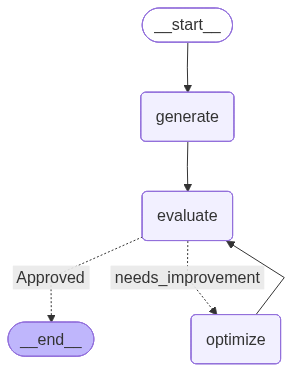

In [11]:
workflow

In [18]:
initial_state = {
    'topic' : "09oplmuhjedf-iuo-o90-poi",
    'iteration': 1,
    'max_iteration': 5

}


In [20]:
result = workflow.invoke(initial_state)

In [21]:
result

{'topic': '09oplmuhjedf-iuo-o90-poi',
 'tweet': 'Just tried to connect to my WiFi and the password was 09oplmuhjedf-iuo-o90-poi. I felt like I’d stumbled into a secret level of a video game, only to realize it’s just a random string that makes me feel like a hacker. #WiFiProblems #PasswordFail 🚀😂',
 'evaluation': 'Approved',
 'feedback': 'The tweet lands well on humor and relatability—most people have been frustrated by absurd Wi‑Fi passwords, and the gamer‑hacker metaphor adds a playful twist. It stays comfortably under the 280‑character limit, uses relevant hashtags, and finishes with emojis that reinforce the light‑hearted tone. The narrative style avoids the classic setup‑punchline structure, so it doesn’t feel forced. A potential tweak would be trimming the sentence about the random string to make it even snappier, but overall it’s punchy enough to catch scroll‑stops and has decent virality potential.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Just tried to connec

In [22]:
for tweet in result['tweet_history']:
    print(tweet)

Just tried to connect to my WiFi and the password was 09oplmuhjedf-iuo-o90-poi. I felt like I’d stumbled into a secret level of a video game, only to realize it’s just a random string that makes me feel like a hacker. #WiFiProblems #PasswordFail 🚀😂
